# GBDT vs NN

Thin orchestration notebook for the default `NN` vs `GBDT` analysis.

In [8]:
from __future__ import annotations

import sys
from pathlib import Path

notebook_dir = Path.cwd()
project_dir = notebook_dir.parent
repo_root = project_dir.parent

sys.path.insert(0, str(project_dir / "src"))
sys.path.insert(0, str(repo_root / "tabarena" / "tabarena"))

In [9]:
from mfa import load_config, run_analysis

config = load_config(project_dir / "configs" / "config_1.yaml")
result = run_analysis(
    config,
    # datasets=[
    #     # "qsar-biodeg", "APSFailure", "Amazon_employee_access",
    #     "Fitness_Club"
    # ],
)
result.analysis_table.head()

10:16:26 INFO mfa.pipeline: Starting analysis: comparisons=tabpfn_old_vs_new; scope=all benchmark datasets; unit=dataset; method_variant=default
10:16:26 INFO mfa.pipeline: Stage 1/5 raw results: loading from TabArena


10:16:27 INFO mfa.pipeline: Stage 1/5 raw results: ready (18606 rows, 51 dataset(s))
10:16:27 INFO mfa.pipeline: Stage 2/5 meta-features: building for all benchmark datasets
10:16:27 INFO mfa.metafeatures: Meta-features: preparing 51 dataset(s) with feature_sets=basic
10:16:27 INFO mfa.metafeatures: Meta-features [1/51] airfoil_self_noise: starting (30 split(s); elapsed 00:00:00)
10:16:27 INFO mfa.metafeatures: Meta-features [1/51] airfoil_self_noise: done in 00:00:00 (0 cached, 30 computed; total elapsed 00:00:00)
10:16:27 INFO mfa.metafeatures: Meta-features [2/51] Amazon_employee_access: starting (9 split(s); elapsed 00:00:00)
10:16:27 INFO mfa.metafeatures: Meta-features [2/51] Amazon_employee_access: done in 00:00:00 (0 cached, 9 computed; total elapsed 00:00:00)
10:16:27 INFO mfa.metafeatures: Meta-features [3/51] anneal: starting (30 split(s); elapsed 00:00:00)
10:16:27 INFO mfa.metafeatures: Meta-features [3/51] anneal: done in 00:00:00 (0 cached, 30 computed; total elapsed 00:

,dataset,comparison_name,group_a_name,group_b_name,group_a_label,group_b_label,expected_direction,n_splits,n,d,...,best_a_error,best_a_norm_error,best_b_error,best_b_norm_error,delta_raw,delta_raw_std,delta_raw_sem,delta_norm,delta_norm_std,delta_norm_sem
0,APSFailure,tabpfn_old_vs_new,tabpfnv2,tabpfnv26,tabpfnv2,tabpfnv26,NaN,9,50666.666667,170.0,...,0.010250,0.977918,0.007312,0.478123,0.002937,0.001796,0.000599,0.499795,0.190008,0.063336
1,Amazon_employee_access,tabpfn_old_vs_new,tabpfnv2,tabpfnv26,tabpfnv2,tabpfnv26,NaN,9,21846.000000,9.0,...,0.160810,0.988333,0.147324,0.751332,0.013486,0.003970,0.001323,0.237001,0.114683,0.038228
2,Another-Dataset-on-used-Fiat-500,tabpfn_old_vs_new,tabpfnv2,tabpfnv26,tabpfnv2,tabpfnv26,NaN,30,1025.333333,7.0,...,727.715649,0.366593,726.458695,0.325651,1.256954,4.705816,0.859161,0.040942,0.147764,0.026978
3,Bank_Customer_Churn,tabpfn_old_vs_new,tabpfnv2,tabpfnv26,tabpfnv2,tabpfnv26,NaN,9,6666.666667,10.0,...,0.128277,0.181621,0.127787,0.127718,0.000490,0.001448,0.000483,0.053904,0.159244,0.053081
4,Bioresponse,tabpfn_old_vs_new,tabpfnv2,tabpfnv26,tabpfnv2,tabpfnv26,NaN,9,2500.666667,1776.0,...,0.127169,0.404328,0.122321,0.066817,0.004848,0.003031,0.001010,0.337511,0.182173,0.060724


In [10]:
import pandas as pd

# -- Inspect what the result object contains --
print(f"config_hash:        {result.config_hash}")
print(f"comparison_name:    {result.comparison_name}")
print(f"analysis_table:     {result.analysis_table.shape}")
print(f"gap_table:          {result.gap_table.shape}")
print(f"metafeature_table:  {result.metafeature_table.shape}")
print(f"correlation_results: {len(result.correlation_results)} features tested")
print(
    f"correction_result:  {result.correction_result.method if result.correction_result else None}"
)
print(f"multivariate_result: {result.multivariate_result}")

config_hash:        beb7636111ce4215
comparison_name:    tabpfn_old_vs_new
analysis_table:     (51, 24)
gap_table:          (816, 17)
metafeature_table:  (816, 9)
correlation_results: 6 features tested
correction_result:  bh
multivariate_result: None


## Correlation summary table

In [11]:
import numpy as np

# Build a comprehensive table from correlation + correction results
corr_df = pd.DataFrame([r.__dict__ for r in result.correlation_results])

if result.correction_result is not None:
    corr_df["p_value_adj"] = result.correction_result.adjusted_p_values
    corr_df["rejected"] = result.correction_result.rejected

# Add a significance star column for quick scanning
p_col = "p_value_adj" if "p_value_adj" in corr_df.columns else "p_value"
corr_df["sig"] = np.where(
    corr_df[p_col] < 0.001,
    "***",
    np.where(corr_df[p_col] < 0.01, "**", np.where(corr_df[p_col] < 0.05, "*", "")),
)

display_cols = [
    "predictor",
    "statistic",
    "ci_lower",
    "ci_upper",
    "p_value",
    *(["p_value_adj", "rejected"] if "p_value_adj" in corr_df.columns else []),
    "sig",
    "n_observations",
    "direction_confirmed",
]

corr_df[display_cols].sort_values("p_value")

,predictor,statistic,ci_lower,ci_upper,p_value,p_value_adj,rejected,sig,n_observations,direction_confirmed
0,n,0.633484,0.421300,0.780678,6.061240e-07,0.000002,True,***,51,None
2,log_n,0.633484,0.421300,0.780678,6.061240e-07,0.000002,True,***,51,None
3,n_over_d,0.373937,0.076009,0.613518,6.870260e-03,0.013741,True,*,51,None
5,missing_fraction,0.232950,-0.017182,0.457169,9.995555e-02,0.141218,False,,51,None
1,d,0.221845,-0.053789,0.478010,1.176815e-01,0.141218,False,,51,None
4,cat_fraction,-0.081842,-0.354824,0.193718,5.680418e-01,0.568042,False,,51,None


## Correlation scatter plots

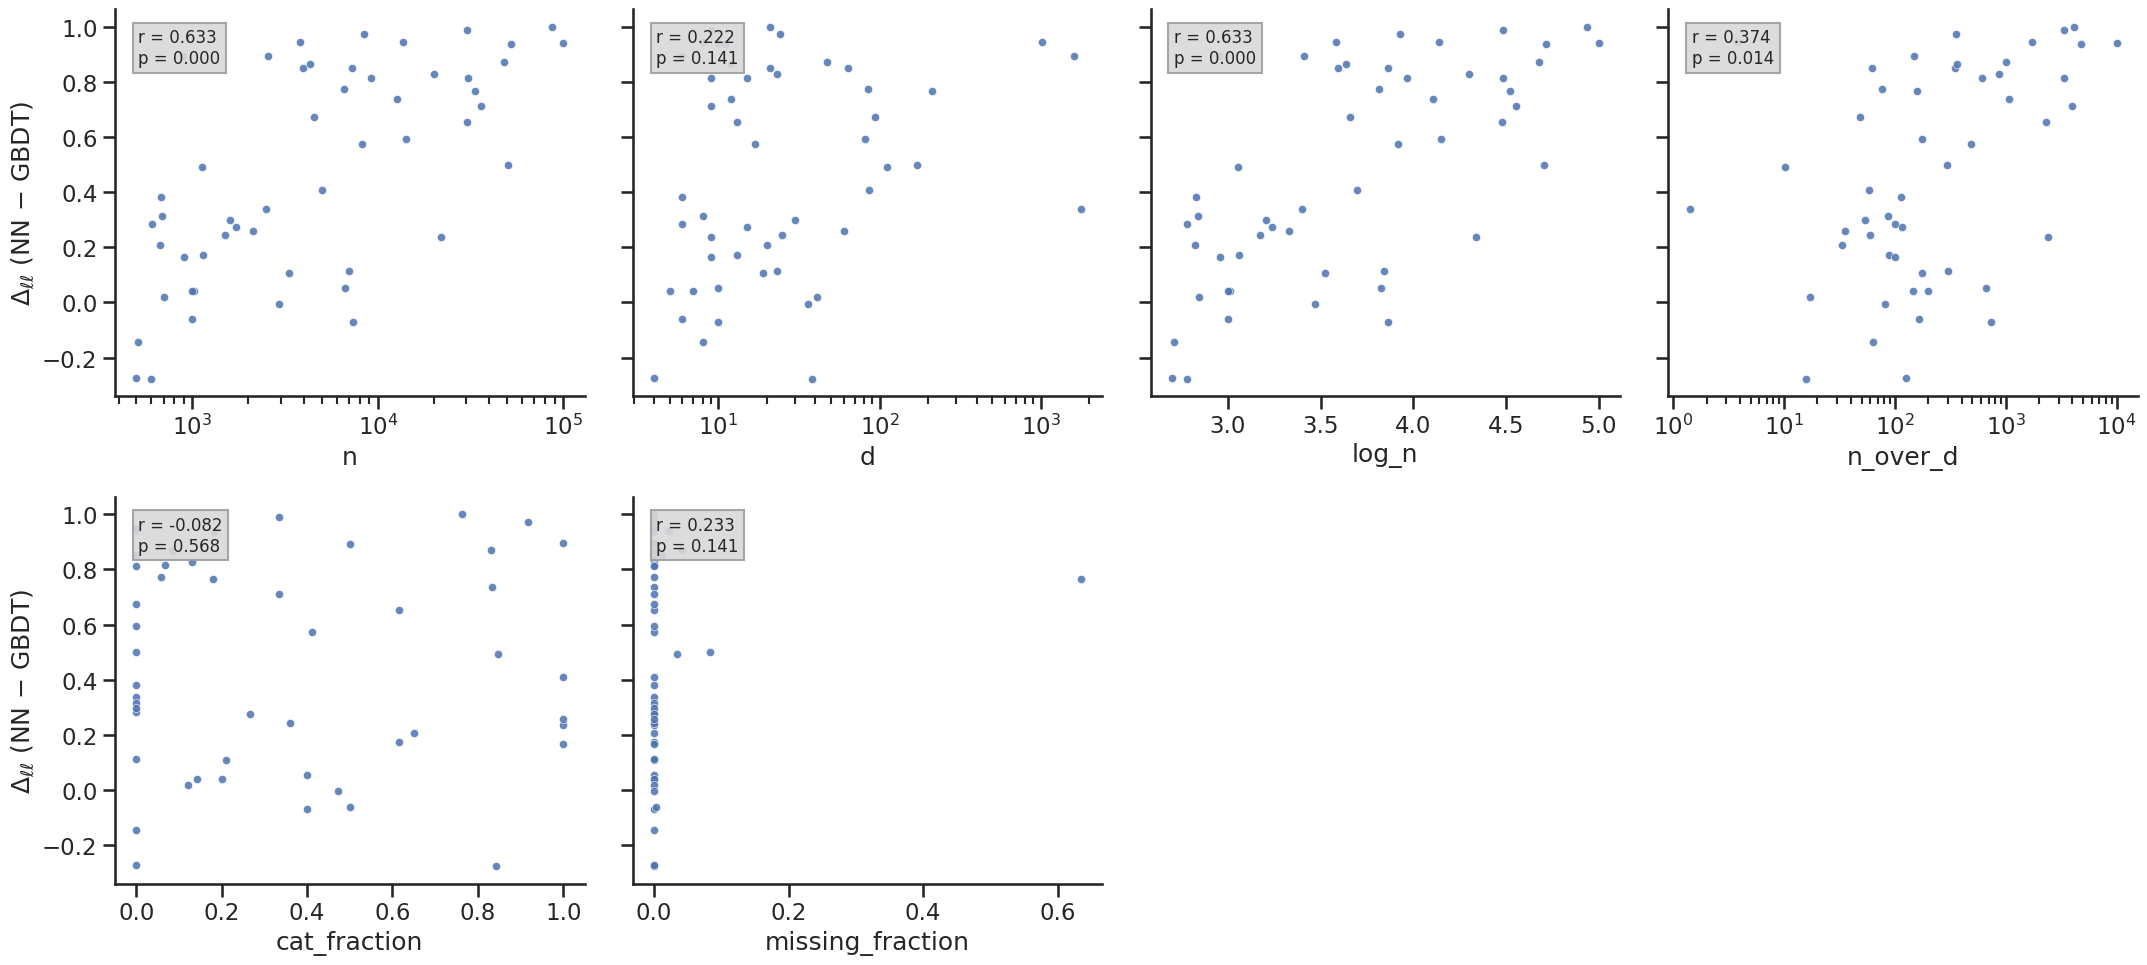

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="talk")

analysis = result.analysis_table.copy()
predictors = corr_df["predictor"].tolist()
n_preds = len(predictors)
ncols = min(4, n_preds)
nrows = int(np.ceil(n_preds / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), sharey=True, squeeze=False
)

for idx, predictor in enumerate(predictors):
    ax = axes[idx // ncols][idx % ncols]
    plot_df = analysis[[predictor, "delta_norm"]].dropna()

    # Use log scale for features that are strictly positive and span orders of magnitude
    use_log = (plot_df[predictor] > 0).all() and (
        plot_df[predictor].max() / plot_df[predictor].min() > 10
    )

    sns.scatterplot(data=plot_df, x=predictor, y="delta_norm", s=35, alpha=0.85, ax=ax)
    if use_log:
        ax.set_xscale("log")

    ax.set_xlabel(predictor)
    if idx % ncols == 0:
        ax.set_ylabel(r"$\Delta_{\ell\ell}$ (NN − GBDT)")
    else:
        ax.set_ylabel("")

    # Annotate with correlation and adjusted p-value
    row = corr_df.loc[corr_df["predictor"] == predictor].iloc[0]
    p_display = row.get("p_value_adj", row["p_value"])
    ax.text(
        0.05,
        0.95,
        f"r = {row['statistic']:.3f}\np = {p_display:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        bbox={"facecolor": "#d9d9d9", "edgecolor": "#9e9e9e", "alpha": 0.9},
    )

# Hide unused subplots
for idx in range(n_preds, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

sns.despine()
fig.tight_layout()
plt.show()